In [1]:
import glob
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tqdm import tqdm
from scipy.fft import fft
import scipy.stats as stats

In [3]:
def extract_surface_type_id(path):
    match = re.search(r'SurfaceTypeID_(\d+)', path)
    return int(match.group(1)) if match else None

data_dir = "../Datasets/Processed_Data/Labeled_Data_Without_GPS"
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["full_path"].apply(extract_surface_type_id)
files_df["device"] = files_df["filename"].apply(lambda x: x.split('_')[3])

print(files_df["surface_id"].value_counts())

files_df.head(2)

surface_id
10    406
9     403
8      98
7      96
6      90
5      66
2      57
3      40
4      30
11     28
12     20
1      10
Name: count, dtype: int64


,full_path,filename,surface_id,device
0,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-15_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7
1,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-09-02_SurfaceTypeID_9_SamsungGalaxyS7_exp...,9,SamsungGalaxyS7


In [4]:
first_file = files_df.iloc[0]['full_path']
df_first = pd.read_csv(first_file)
df_first.head(1)

,sensorName,valueX,valueY,valueZ,timestamp
0,Gyroscope,-0.001634,-0.007524,-0.000831,1.550261e+12


# Basic feature extraction

In [5]:

# Feature extraction code goes here (not shown in the provided snippets)

def zero_crossing_rate(signal):
    return ((signal[:-1] * signal[1:]) < 0).sum()

acc_result_list = []
gyro_result_list = []

acc_window_list = []
gyro_window_list = []

WINDOW_SIZE = 1024
STEP_SIZE = WINDOW_SIZE // 2
window_counter = 0

for idx, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    file_path = row['full_path']
    surface_id = row['surface_id']
    
    data_df = pd.read_csv(file_path)

    # Pad if data is shorter than one window
    if len(data_df) < WINDOW_SIZE:
        pad_size = WINDOW_SIZE - len(data_df)
        pad_df   = pd.concat([data_df] * (pad_size // len(data_df) + 1)).iloc[:pad_size]
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    # Pad last incomplete window with edge values
    remainder = len(data_df) % STEP_SIZE
    if remainder != 0:
        pad_size = WINDOW_SIZE - remainder
        pad_df   = data_df.iloc[-pad_size:].copy()
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)


    for start in range(0, len(data_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data_df[start:start + WINDOW_SIZE]

        window_counter += 1

        window_xyz =  window[['valueX', 'valueY', 'valueZ']].copy()
        window_xyz['surface_id'] = surface_id
        window_xyz['window_id'] = window_counter

        svm = np.sqrt(window['valueX']**2 + window['valueY']**2 + window['valueZ']**2)

        fft_val_x = np.abs(np.fft.fft(window['valueX'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_y = np.abs(np.fft.fft(window['valueY'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_z = np.abs(np.fft.fft(window['valueZ'].to_numpy()))[:WINDOW_SIZE//2]

        features = {

            # Time domain features
            'mean_x': window['valueX'].mean(),
            'mean_y': window['valueY'].mean(),
            'mean_z': window['valueZ'].mean(),
            'std_x': window['valueX'].std(),
            'std_y': window['valueY'].std(),
            'std_z': window['valueZ'].std(),
            'var_x': window['valueX'].var(),
            'var_y': window['valueY'].var(),
            'var_z': window['valueZ'].var(),
            'sum_x': window['valueX'].sum(),
            'sum_y': window['valueY'].sum(),
            'sum_z': window['valueZ'].sum(),
            'max_x': window['valueX'].max(),
            'max_y': window['valueY'].max(),
            'max_z': window['valueZ'].max(),
            'min_x': window['valueX'].min(),
            'min_y': window['valueY'].min(),
            'min_z': window['valueZ'].min(),

            # Higher-order statistics
            'skew_x': stats.skew(window['valueX']),
            'kurt_x': stats.kurtosis(window['valueX']),
            'skew_y': stats.skew(window['valueY']),
            'kurt_y': stats.kurtosis(window['valueY']),
            'skew_z': stats.skew(window['valueZ']),
            'kurt_z': stats.kurtosis(window['valueZ']),

            # Zero Crossing Rate
            'zcr_x': zero_crossing_rate(window['valueX'].values),
            'zcr_y': zero_crossing_rate(window['valueY'].values),
            'zcr_z': zero_crossing_rate(window['valueZ'].values),

            # Single Vector Magnitude (SVM) features
            'svm_mean': svm.mean(),
            'svm_std':  svm.std(),
            'svm_max':  svm.max(),

            # Axis correlations
            'corr_xy': window['valueX'].corr(window['valueY']),
            'corr_xz': window['valueX'].corr(window['valueZ']),
            'corr_yz': window['valueY'].corr(window['valueZ']),

            # Frequency domain features
            'dominant_freq_x': np.argmax(fft_val_x),
            'spectral_energy_x': np.sum(fft_val_x**2),
            'spectral_entropy_x': -np.sum((fft_val_x/fft_val_x.sum()) * np.log(fft_val_x/fft_val_x.sum() + 1e-10)),
            
            'dominant_freq_y': np.argmax(fft_val_y),
            'spectral_energy_y': np.sum(fft_val_y**2),
            'spectral_entropy_y': -np.sum((fft_val_y/fft_val_y.sum()) * np.log(fft_val_y/fft_val_y.sum() + 1e-10)),
            
            'dominant_freq_z': np.argmax(fft_val_z),
            'spectral_energy_z': np.sum(fft_val_z**2),
            'spectral_entropy_z': -np.sum((fft_val_z/fft_val_z.sum()) * np.log(fft_val_z/fft_val_z.sum() + 1e-10)),
            
            'surface_id': surface_id,
        }

        if 'accelerometer' in file_path.lower():
            acc_result_list.append(features)
            acc_window_list.append(window_xyz)
        elif 'gyroscope' in file_path.lower():
            gyro_result_list.append(features)

Processing files: 100%|██████████| 1344/1344 [00:31<00:00, 42.96it/s] 


In [6]:
print(f"Extracted features from {len(acc_result_list)} accelerometer windows and {len(gyro_result_list)} gyroscope windows.")

Extracted features from 7962 accelerometer windows and 7890 gyroscope windows.


In [8]:
# Create DataFrames from the extracted features
acc_df = pd.DataFrame(acc_result_list)
gyro_df = pd.DataFrame(gyro_result_list)

# Create output directory if it doesn't exist
output_dir = "../Datasets/ExtractedFeatures"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Save feature CSVs
acc_df.to_csv(os.path.join(output_dir, "labeled_accelerometer_features.csv"), index=False)
gyro_df.to_csv(os.path.join(output_dir, "labeled_gyroscope_features.csv"), index=False)

# Save raw windowed data (valueX, valueY, valueZ, surface_id, window_id) as CSV
acc_windows_df = pd.concat(acc_window_list, ignore_index=True)
acc_windows_df.to_csv(os.path.join(output_dir, "labeled_accelerometer_raw_windows.csv"), index=False)

print(f"Accelerometer features saved: {len(acc_df)} samples")
print(f"Gyroscope features saved: {len(gyro_df)} samples")
print(f"Accelerometer windows saved: {len(acc_windows_df)} rows ({len(acc_window_list)} windows)")

Accelerometer features saved: 7962 samples
Gyroscope features saved: 7890 samples
Accelerometer windows saved: 8153088 rows (7962 windows)


In [15]:
pd.read_csv(os.path.join(output_dir, "labeled_accelerometer_raw_windows.csv")).head(3)

,valueX,valueY,valueZ,surface_id,window_id
0,-1.369181,0.157057,-0.332538,9,2
1,1.693364,-2.061905,0.230769,9,2
2,0.990205,-3.759830,4.920473,9,2


# Feature Extraction for continuous europe data

In [48]:
europe_data_dir = "../Datasets/Processed_Data/Unlabeled_Data_With_GPS/Europe"
europe_file_paths = glob.glob(os.path.join(europe_data_dir, "**", "*.csv"), recursive=True)

europe_files_df = pd.DataFrame({
    "full_path": europe_file_paths,
    "filename": [os.path.basename(p) for p in europe_file_paths],
})


print(f"Found {len(europe_files_df)} CSV files")
europe_files_df.head(2)

Found 25 CSV files


,full_path,filename
0,../Datasets/Processed_Data/Unlabeled_Data_With...,Avenue_des_Champs_Elysees_AccelerometerData.csv
1,../Datasets/Processed_Data/Unlabeled_Data_With...,Eiffel_Tower_AccelerometerData.csv


In [49]:
import numpy as np
from dataclasses import dataclass


@dataclass
class ActivityProfile:
    svm_var_p20:        float
    axis_var_p20:       float
    active_ratio_p20:   float
    quarter_ratio_p75:  float
    active_threshold:   float


def build_activity_profile(df, eps: float = 1e-4) -> ActivityProfile:
    """
    Build activity profile directly from raw DataFrame signal distribution.

    Args:
        df: Full DataFrame with columns ['valueX', 'valueY', 'valueZ']

    Returns:
        ActivityProfile with learned thresholds.
    """
    svm = np.sqrt(
        df['valueX']**2 +
        df['valueY']**2 +
        df['valueZ']**2
    ).values

    active_threshold = float(np.percentile(svm, 20))

    roll_window = max(10, len(svm) // 100)

    rolling_var = (
        df[['valueX', 'valueY', 'valueZ']]
        .pow(2).sum(axis=1)
        .rolling(roll_window)
        .var()
        .dropna()
        .values
    )

    axis_rolling_var = (
        df[['valueX', 'valueY', 'valueZ']]
        .rolling(roll_window)
        .var()
        .dropna()
        .mean(axis=1)
        .values
    )

    return ActivityProfile(
        svm_var_p20       = float(np.percentile(rolling_var,      20)),
        axis_var_p20      = float(np.percentile(axis_rolling_var, 20)),
        active_ratio_p20  = float((svm > active_threshold).mean() * 0.60),
        quarter_ratio_p75 = float(np.percentile(rolling_var, 75) /
                                  (np.percentile(rolling_var, 25) + eps)),
        active_threshold  = active_threshold,
    )


def _compute_window_features(svm: np.ndarray, axis_var_mean: float,
                              active_threshold: float, eps: float = 1e-4) -> dict:
    """Extract all activity features for a single window."""
    N_SEG   = 10
    seg_len = max(1, len(svm) // N_SEG)
    seg_vars = np.array([
        svm[i * seg_len:(i + 1) * seg_len].var()
        for i in range(N_SEG)
    ])
    total_var = seg_vars.sum() + eps

    seg_var_cv        = seg_vars.std() / (seg_vars.mean() + eps)
    top3_energy_ratio = np.sort(seg_vars)[-3:].sum() / total_var
    bottom3_var_mean  = np.sort(seg_vars)[:3].mean()

    quarter = max(1, len(svm) // 4)
    fq_var  = svm[:quarter].var()
    lq_var  = svm[-quarter:].var()
    mid_var = svm[quarter:-quarter].var()
    quarter_ratio     = (max(fq_var, lq_var) + eps) / (min(fq_var, lq_var) + eps)
    peak_to_floor     = (seg_vars.max() + eps) / (bottom3_var_mean + eps)

    # fraction of segments with near-zero variance
    dead_zone_ratio   = (seg_vars < (seg_vars.max() * 0.02)).mean()

    active_ratio      = (svm > active_threshold).mean()

    return {
        'svm_var':           svm.var(),
        'axis_var_mean':     axis_var_mean,
        'active_ratio':      active_ratio,
        'seg_cv':            seg_var_cv,
        'top3_energy_ratio': top3_energy_ratio,
        'quarter_ratio':     quarter_ratio,
        'peak_to_floor':     peak_to_floor,
        'dead_zone_ratio':   dead_zone_ratio,
        'mid_var':           mid_var,
    }


def is_stalled_window(window, profile: ActivityProfile, eps: float = 1e-4) -> bool:
    """
    Detect stalled/burst/stall-then-burst windows.

    Args:
        window  : pd.DataFrame slice with ['valueX', 'valueY', 'valueZ']
        profile : Built from build_activity_profile(df)

    Returns:
        bool: True if window should be skipped.
    """
    svm = np.sqrt(
        window['valueX']**2 +
        window['valueY']**2 +
        window['valueZ']**2
    ).values

    axis_var_mean = window[['valueX', 'valueY', 'valueZ']].var(ddof=0).mean()
    f = _compute_window_features(svm, axis_var_mean, profile.active_threshold, eps)

    # ── 1. Low overall activity ───────────────────────────────────────────────
    low_activity = (
        f['svm_var']       < profile.svm_var_p20 or
        f['axis_var_mean'] < profile.axis_var_p20
    )

    # ── 2. Sparse active samples ──────────────────────────────────────────────
    sparse_activity = f['active_ratio'] < profile.active_ratio_p20

    # ── 3. Burst / stall-then-burst pattern ───────────────────────────────────
    # Relaxed slightly vs previous version to avoid false positives
    energy_clumped  = f['top3_energy_ratio'] > 0.85   # was 0.80
    high_peak_floor = f['peak_to_floor']     > 25.0   # was 20.0
    has_dead_zones  = f['dead_zone_ratio']   > 0.35   # was 0.30
    quarter_skewed  = f['quarter_ratio']     > profile.quarter_ratio_p75

    burst_pattern = (
        (energy_clumped  and has_dead_zones)   or
        (high_peak_floor and sparse_activity)  or
        (quarter_skewed  and has_dead_zones)
    )

    # ── 4. Decaying / ramping signal ──────────────────────────────────────────
    edge_mean_var = (svm[:len(svm)//4].var() + svm[-len(svm)//4:].var()) / 2
    decaying      = (edge_mean_var / (f['mid_var'] + eps)) > 6.0 and sparse_activity  # was 5.0

    return low_activity or burst_pattern or decaying

In [50]:

# Feature extraction code goes here (not shown in the provided snippets)

def zero_crossing_rate(signal):
    return ((signal[:-1] * signal[1:]) < 0).sum()

europe_acc_result_list = []
europe_acc_window_list = []

WINDOW_SIZE = 1024
STEP_SIZE = WINDOW_SIZE // 2
window_counter = 0
skipped_stalled = 0

for idx, row in tqdm(europe_files_df.iterrows(), total=len(europe_files_df), desc="Processing files"):
    file_path = row['full_path']
    surface_id = row.get('surface_id', None)
    
    data_df = pd.read_csv(file_path)
    profile = build_activity_profile(data_df)

    test_df = data_df.copy()

    for start in range(0, len(data_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data_df[start:start + WINDOW_SIZE]

        # Skip stalled windows (rare movement or no movement):
        if is_stalled_window(window, profile):
            
            # assign zero too all axis values on test_df for visualization
            test_df.iloc[start:start + WINDOW_SIZE, test_df.columns.get_loc('valueX')] = 0
            test_df.iloc[start:start + WINDOW_SIZE, test_df.columns.get_loc('valueY')] = 0
            test_df.iloc[start:start + WINDOW_SIZE, test_df.columns.get_loc('valueZ')] = 0

            skipped_stalled += 1
            continue

        window_counter += 1

        window_xyz =  window[['valueX', 'valueY', 'valueZ']].copy()
        window_xyz['surface_id'] = surface_id
        window_xyz['window_id'] = window_counter

        svm = np.sqrt(window['valueX']**2 + window['valueY']**2 + window['valueZ']**2)

        fft_val_x = np.abs(np.fft.fft(window['valueX'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_y = np.abs(np.fft.fft(window['valueY'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_z = np.abs(np.fft.fft(window['valueZ'].to_numpy()))[:WINDOW_SIZE//2]

        features = {

            # Time domain features
            'mean_x': window['valueX'].mean(),
            'mean_y': window['valueY'].mean(),
            'mean_z': window['valueZ'].mean(),
            'std_x': window['valueX'].std(),
            'std_y': window['valueY'].std(),
            'std_z': window['valueZ'].std(),
            'var_x': window['valueX'].var(),
            'var_y': window['valueY'].var(),
            'var_z': window['valueZ'].var(),
            'sum_x': window['valueX'].sum(),
            'sum_y': window['valueY'].sum(),
            'sum_z': window['valueZ'].sum(),
            'max_x': window['valueX'].max(),
            'max_y': window['valueY'].max(),
            'max_z': window['valueZ'].max(),
            'min_x': window['valueX'].min(),
            'min_y': window['valueY'].min(),
            'min_z': window['valueZ'].min(),

            # Higher-order statistics
            'skew_x': stats.skew(window['valueX']),
            'kurt_x': stats.kurtosis(window['valueX']),
            'skew_y': stats.skew(window['valueY']),
            'kurt_y': stats.kurtosis(window['valueY']),
            'skew_z': stats.skew(window['valueZ']),
            'kurt_z': stats.kurtosis(window['valueZ']),

            # Zero Crossing Rate
            'zcr_x': zero_crossing_rate(window['valueX'].values),
            'zcr_y': zero_crossing_rate(window['valueY'].values),
            'zcr_z': zero_crossing_rate(window['valueZ'].values),

            # Single Vector Magnitude (SVM) features
            'svm_mean': svm.mean(),
            'svm_std':  svm.std(),
            'svm_max':  svm.max(),

            # Axis correlations
            'corr_xy': window['valueX'].corr(window['valueY']),
            'corr_xz': window['valueX'].corr(window['valueZ']),
            'corr_yz': window['valueY'].corr(window['valueZ']),

            # Frequency domain features
            'dominant_freq_x': np.argmax(fft_val_x),
            'spectral_energy_x': np.sum(fft_val_x**2),
            'spectral_entropy_x': -np.sum((fft_val_x/fft_val_x.sum()) * np.log(fft_val_x/fft_val_x.sum() + 1e-10)),
            
            'dominant_freq_y': np.argmax(fft_val_y),
            'spectral_energy_y': np.sum(fft_val_y**2),
            'spectral_entropy_y': -np.sum((fft_val_y/fft_val_y.sum()) * np.log(fft_val_y/fft_val_y.sum() + 1e-10)),
            
            'dominant_freq_z': np.argmax(fft_val_z),
            'spectral_energy_z': np.sum(fft_val_z**2),
            'spectral_entropy_z': -np.sum((fft_val_z/fft_val_z.sum()) * np.log(fft_val_z/fft_val_z.sum() + 1e-10)),
            
            'surface_id': surface_id,
        }

        europe_acc_result_list.append(features)
        europe_acc_window_list.append(window_xyz)

print(f"Extracted features from {len(europe_acc_result_list)} accelerometer windows.")
print(f"Skipped {skipped_stalled} stalled windows.")


Processing files: 100%|██████████| 25/25 [03:21<00:00,  8.04s/it]

Extracted features from 23674 accelerometer windows.
Skipped 27287 stalled windows.


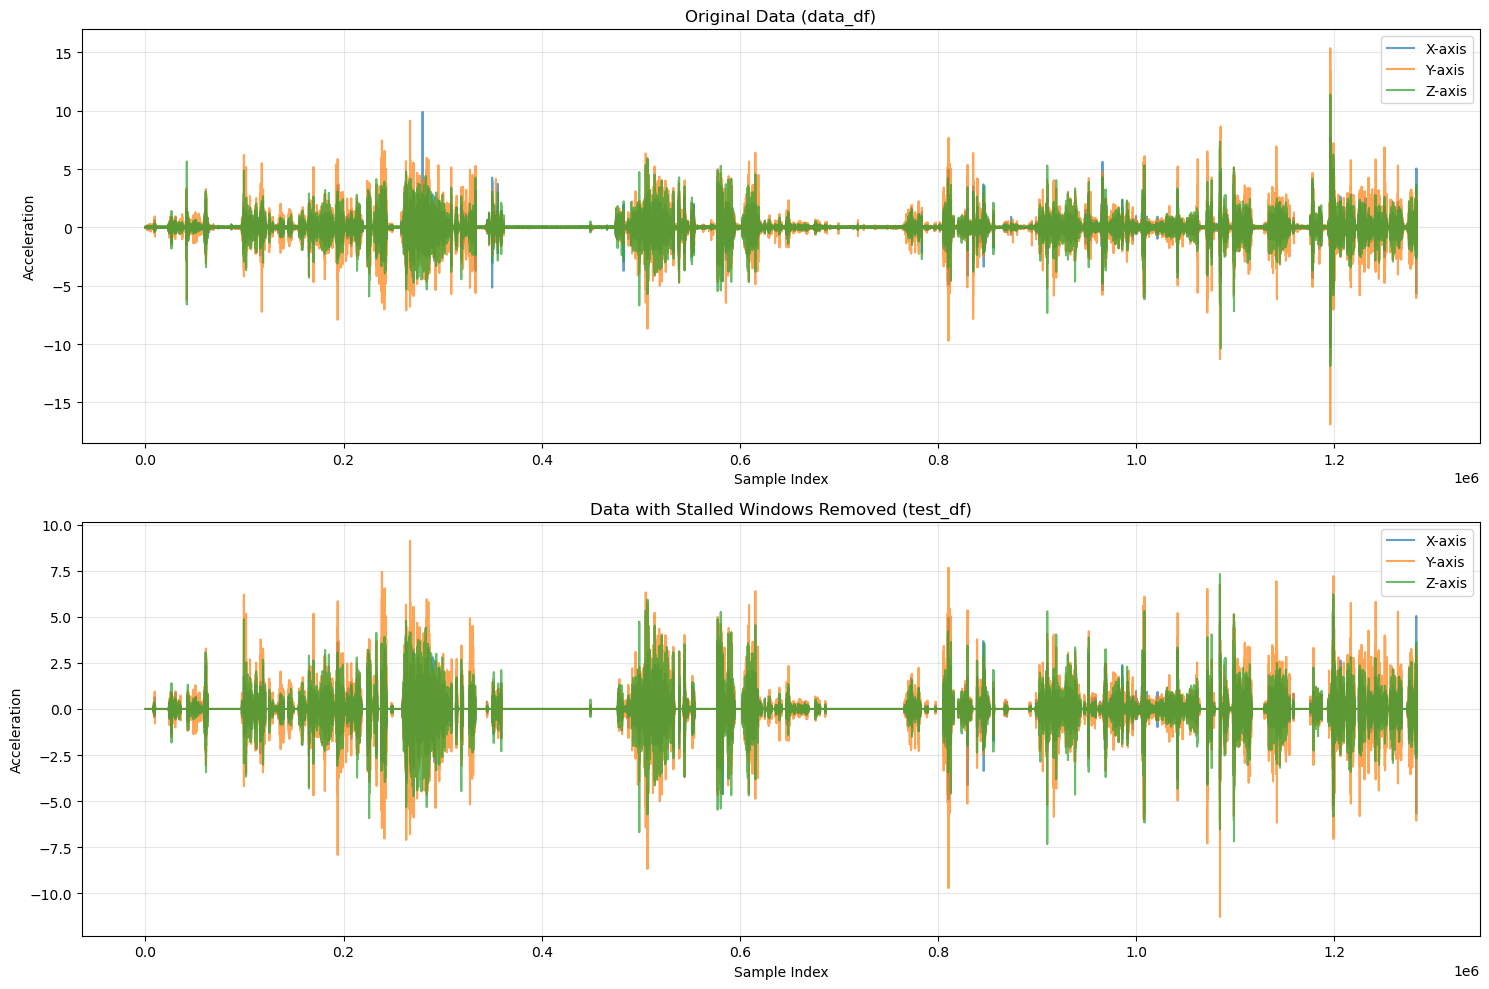

Total samples: 1282855
Stalled windows removed: 27287
Active windows kept: 23674


In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot original data_df
ax1.plot(data_df['valueX'], label='X-axis', alpha=0.7)
ax1.plot(data_df['valueY'], label='Y-axis', alpha=0.7)
ax1.plot(data_df['valueZ'], label='Z-axis', alpha=0.7)
ax1.set_title('Original Data (data_df)')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Acceleration')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot test_df with stalled windows zeroed out
ax2.plot(test_df['valueX'], label='X-axis', alpha=0.7)
ax2.plot(test_df['valueY'], label='Y-axis', alpha=0.7)
ax2.plot(test_df['valueZ'], label='Z-axis', alpha=0.7)
ax2.set_title('Data with Stalled Windows Removed (test_df)')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Acceleration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total samples: {len(data_df)}")
print(f"Stalled windows removed: {skipped_stalled}")
print(f"Active windows kept: {window_counter}")

In [52]:
# for item in europe_acc_window_list:
#     # plot time series
#     plt.figure(figsize=(12, 4))
#     plt.plot(item['valueX'], label='X-axis')
#     plt.plot(item['valueY'], label='Y-axis')
#     plt.plot(item['valueZ'], label='Z-axis')
#     plt.title(f"Accelerometer Window {item['window_id'].iloc[0]}")
#     plt.xlabel("Time")
#     plt.ylabel("Acceleration")
#     plt.legend()

#     plt.savefig(f"exp/window_{item['window_id'].iloc[0]}.png")
#     plt.close()

In [53]:
# Create DataFrames from the extracted features
europe_acc_df = pd.DataFrame(europe_acc_result_list)

# Create output directory if it doesn't exist
output_dir = "../Datasets/ExtractedFeatures"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Save feature CSVs
europe_acc_df.to_csv(os.path.join(output_dir, "unlabeled_accelerometer_features.csv"), index=False)

# Save raw windowed data (valueX, valueY, valueZ, surface_id, window_id) as CSV
europe_acc_windows_df = pd.concat(europe_acc_window_list, ignore_index=True)
europe_acc_windows_df.to_csv(os.path.join(output_dir, "unlabeled_accelerometer_raw_windows.csv"), index=False)

print(f"Accelerometer features saved: {len(europe_acc_df)} samples")
print(f"Accelerometer windows saved: {len(europe_acc_windows_df)} rows ({len(europe_acc_window_list)} windows)")

Accelerometer features saved: 23674 samples
Accelerometer windows saved: 24242176 rows (23674 windows)
